<a href="https://colab.research.google.com/github/wataruhisano/MLB_salary_prediction/blob/main/4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pybaseball mlb-statsapi duckdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.9 MB/s eta 0:00:00


In [2]:
import os
import pandas as pd
import duckdb
import re
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import shutil
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# 1. マウント

drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [4]:
# --- 1. 設定  ---
DRIVE_PATH = '/content/drive/My Drive/個人開発/MLB_DATA_PREDICT/data/'
LOCAL_DB_PATH = '/content/mlb_analytics.duckdb'
SALARY_CSV = os.path.join(DRIVE_PATH, 'mlb_salary_data.csv')


In [5]:
# 既存のDBがあればDriveからローカルにコピー（継続開発用）

if os.path.exists(os.path.join(DRIVE_PATH, 'mlb_analytics.duckdb')):

    shutil.copy(os.path.join(DRIVE_PATH, 'mlb_analytics.duckdb'), LOCAL_DB_PATH)

    print("Existing database copied from Drive to local.")

Existing database copied from Drive to local.


In [6]:
# DuckDB接続
con = duckdb.connect(LOCAL_DB_PATH)

In [7]:
# --- 2. データクリーニング関数の定義 ---
def clean_salary(x):
    """$5,850,000 のような文字列を数値に変換"""
    if isinstance(x, str):
        return float(re.sub(r'[$,]', '', x))
    return x

def clean_name(x):
    """Matt Wallner* のような名前末尾の記号を除去"""
    if isinstance(x, str):
        return re.sub(r'[*#]', '', x).strip()
    return x

In [8]:
# --- 3. Salaryデータの読み込みとDuckDB格納 ---
if os.path.exists(SALARY_CSV):
    salary_raw = pd.read_csv(SALARY_CSV, encoding='latin1')
    # クリーニング
    salary_raw['Salary_Numeric'] = salary_raw['Salary'].apply(clean_salary)
    salary_raw['Name_Clean'] = salary_raw['Name'].apply(clean_name)

    # DuckDBへテーブル作成
    con.execute("CREATE OR REPLACE TABLE t_salary AS SELECT * FROM salary_raw")
    print("Salary data loaded and stored in DuckDB.")
else:
    print("エラー: Salary CSVが見つかりません。")

Salary data loaded and stored in DuckDB.


In [9]:
# --- 4. 年度別Baseball Referenceデータの読み込み (2022-2024) ---
# ファイル名が '2022_stats.csv' 等であると仮定（適宜修正してください）
years = [2017,2018,2019,2021,2022, 2023, 2024]
all_stats_list = []

for year in years:
    # ファイルパス構築（例: DRIVE_PATH/2022_stats.csv）
    stats_file = os.path.join(DRIVE_PATH, f'{year}_stats.csv')

    if os.path.exists(stats_file):
        df = pd.read_csv(stats_file)
        df['Year'] = year
        # 提示された形式に基づき、Nameのクレンジング
        if 'Name' in df.columns:
            df['Name_Clean'] = df['Name'].apply(clean_name)
        else:

            df['Name_Clean'] = df.iloc[:, 1].apply(clean_name)

        all_stats_list.append(df)
        print(f"Loaded stats for {year}")

if all_stats_list:
    full_stats_df = pd.concat(all_stats_list)
    con.execute("CREATE OR REPLACE TABLE t_stats AS SELECT * FROM full_stats_df")
else:
    print("エラー: 年度別の統計データが見つかりません。")

Loaded stats for 2017
Loaded stats for 2018
Loaded stats for 2019
Loaded stats for 2021
Loaded stats for 2022
Loaded stats for 2023
Loaded stats for 2024


In [10]:
# --- 4.5 FanGraphsデータの読み込み (2022-2024) ---
# ファイル名が 'fg_stats_2022.csv' 等であると仮定
fg_years =  [2017,2018,2019,2021,2022, 2023, 2024]
all_fg_list = []

for year in fg_years:
    fg_file = os.path.join(DRIVE_PATH, f'fg_stats_{year}.csv') # 実際のファイル名に変更してください

    if os.path.exists(fg_file):
        df_fg = pd.read_csv(fg_file)
        df_fg['Year'] = year

        # 名前列の特定とクレンジング
        # FGは1列目に "1Aaron Judge" のように番号がくっついている場合があるため注意
        if 'Name' in df_fg.columns:
            df_fg['Name_Clean'] = df_fg['Name'].apply(clean_name)
        else:
            # 列名がない場合、1列目を加工
            df_fg['Name_Clean'] = df_fg.iloc[:, 0].str.replace(r'^\d+', '', regex=True).apply(clean_name)

        all_fg_list.append(df_fg)
        print(f"Loaded FanGraphs {year}")

if all_fg_list:
    full_fg_df = pd.concat(all_fg_list)
    # DuckDBへ格納 (既にある指標と重複を避けるためテーブル名を分ける)
    con.execute("CREATE OR REPLACE TABLE t_fg_stats AS SELECT * FROM full_fg_df")
else:
    print("エラー: FanGraphsデータが見つかりません。")

Loaded FanGraphs 2017
Loaded FanGraphs 2018
Loaded FanGraphs 2019
Loaded FanGraphs 2021
Loaded FanGraphs 2022
Loaded FanGraphs 2023
Loaded FanGraphs 2024


In [11]:
# それぞれのテーブルから名前を5件ずつ表示して形式を比較
print("--- t_stats の名前サンプル ---")
print(con.execute("SELECT Name_Clean, Year FROM t_stats LIMIT 5").df())

print("\n--- t_salary の名前サンプル ---")
print(con.execute("SELECT Name_Clean, Year FROM t_salary LIMIT 5").df())

--- t_stats の名前サンプル ---
          Name_Clean  Year
0        Jose Altuve  2017
1        Aaron Judge  2017
2  Giancarlo Stanton  2017
3  Andrelton Simmons  2017
4         Joey Votto  2017

--- t_salary の名前サンプル ---
      Name_Clean  Year
0  Kelly Johnson  2011
1   Joe Saunders  2011
2    Chris Young  2011
3   Stephen Drew  2011
4   Justin Upton  2011


In [12]:
# --- 5.1 過去実績スコアの事前計算 ---
award_query = """
CREATE OR REPLACE TEMP TABLE t_career_awards AS
WITH award_flags AS (
    SELECT
        Name_Clean,
        Year,
        -- 文字列からフラグ化（正規表現で数字が含まれていても検知可能に）
        CASE WHEN Awards LIKE '%MVP%' THEN 1 ELSE 0 END as mvp_f,
        CASE WHEN Awards LIKE '%SS%'  THEN 1 ELSE 0 END as ss_f,
        CASE WHEN Awards LIKE '%GG%'  THEN 1 ELSE 0 END as gg_f,
        CASE WHEN Awards LIKE '%AS%'  THEN 1 ELSE 0 END as as_f
    FROM t_stats
)
SELECT
    Name_Clean,
    Year,
    -- 去年から5年前までの合計
    SUM(mvp_f) OVER (PARTITION BY Name_Clean ORDER BY Year ROWS BETWEEN 5 PRECEDING AND 1 PRECEDING) as mvp_5yr,
    SUM(ss_f)  OVER (PARTITION BY Name_Clean ORDER BY Year ROWS BETWEEN 5 PRECEDING AND 1 PRECEDING) as ss_5yr,
    SUM(gg_f)  OVER (PARTITION BY Name_Clean ORDER BY Year ROWS BETWEEN 5 PRECEDING AND 1 PRECEDING) as gg_5yr,
    SUM(as_f)  OVER (PARTITION BY Name_Clean ORDER BY Year ROWS BETWEEN 5 PRECEDING AND 1 PRECEDING) as as_5yr
FROM award_flags;
"""
con.execute(award_query)

In [13]:
# --- 5.2 メインのデータ結合 (実績スコアを追加) ---
query = """
SELECT
    s.*,
    s.Age * s.Age as Age_Squared,
    ah.mvp_5yr,
    ah.ss_5yr,
    ah.gg_5yr,
    ah.as_5yr,
    (COALESCE(ah.mvp_5yr, 0) * 10 + COALESCE(ah.ss_5yr, 0) * 3 +
     COALESCE(ah.gg_5yr, 0) * 2 + COALESCE(ah.as_5yr, 0) * 1) as career_award_score,

    f.wOBA, f.xwOBA, f."wRC+", f.BsR, f.Off, f.Def, f.ISO, f.BABIP,
    f.AVG AS f_AVG, f.OBP AS f_OBP, f.SLG AS f_SLG, f."BB%", f."K%",
    f.WAR AS fWAR, f.HR AS f_HR,
    y.Salary_Numeric AS target_salary
FROM t_stats s
JOIN t_fg_stats f
  ON trim(LOWER(CAST(s.Name_Clean AS VARCHAR))) = trim(LOWER(CAST(f.Name_Clean AS VARCHAR)))
 AND s.Year = f.Year
JOIN t_salary y
  ON trim(LOWER(CAST(s.Name_Clean AS VARCHAR))) = trim(LOWER(CAST(y.Name_Clean AS VARCHAR)))
 AND s.Year = y.Year
-- ここで作成した実績テーブルを結合
LEFT JOIN t_career_awards ah
  ON trim(LOWER(CAST(s.Name_Clean AS VARCHAR))) = trim(LOWER(CAST(ah.Name_Clean AS VARCHAR)))
 AND s.Year = ah.Year
WHERE y.Salary_Numeric > 0
"""

df_model = con.execute(query).df()
# Bref側のWARを bWAR にリネームして区別
if 'WAR' in df_model.columns:
    df_model = df_model.rename(columns={'WAR': 'WAR(bref)'})

# FanGraphs側のWARを fWAR にリネームして区別
if 'fWAR' in df_model.columns:
    df_model = df_model.rename(columns={'fWAR': 'WAR(fg)'})

df_model.drop(['Player', 'Rk'], axis=1, inplace=True) # 不要な列

# 欠損値（過去実績がない若手など）を0埋め
award_cols = ['mvp_5yr', 'ss_5yr', 'gg_5yr', 'as_5yr', 'career_award_score']
df_model[award_cols] = df_model[award_cols].fillna(0)

In [14]:
df_model.shape

(1360, 46)

In [15]:
display(df_model[:].head())

,Age,Team,Lg,PA,Rbat,Rbaser,Rdp,Rfield,Rpos,RAA,...,ISO,BABIP,f_AVG,f_OBP,f_SLG,BB%,K%,WAR(fg),f_HR,target_salary
0,25,SEA,AL,550,2,1,2,-8,-5,-9,...,0.137525,0.340369,0.275049,0.322404,0.412574,0.065455,0.221818,0.992790,11,464757.0
1,25,MIA,NL,670,14,1,0,0,-2,13,...,0.127119,0.331858,0.272881,0.356716,0.400000,0.092537,0.192537,3.005781,11,545000.0
2,26,MIA,NL,520,10,0,-1,10,-1,18,...,0.206972,0.304878,0.261438,0.342308,0.468410,0.084615,0.219231,2.775387,20,585000.0
3,24,MIL,NL,619,-10,7,2,22,5,26,...,0.094812,0.300000,0.254025,0.315961,0.348837,0.080775,0.169628,2.561675,7,1116214.0
4,28,MIA,NL,551,6,0,2,-19,-6,-17,...,0.156313,0.336232,0.264529,0.330309,0.420842,0.052632,0.254083,0.438961,16,2900000.0


In [16]:
# データの形状と型の構成を確認
print(f"データ件数: {len(df_model)} 行")
print(f"カラム数: {len(df_model.columns)} 列")

# 数値型の列とオブジェクト型の列を分ける
num_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
obj_cols = df_model.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\n数値指標 ({len(num_cols)}個): {num_cols}")
print(f"カテゴリ指標 ({len(obj_cols)}個): {obj_cols}")

# 欠損値が多い順に表示（上位10項目）
print("\n--- 欠損値が多い指標 TOP 10 ---")
print(df_model.isnull().sum().sort_values(ascending=False).head(10))

データ件数: 1360 行
カラム数: 46 列

数値指標 (40個): ['Age', 'PA', 'Rbat', 'Rbaser', 'Rdp', 'Rfield', 'Rpos', 'RAA', 'WAA', 'Rrep', 'RAR', 'WAR(bref)', 'waaWL%', '162WL%', 'oWAR', 'dWAR', 'oRAR', 'Year', 'Age_Squared', 'mvp_5yr', 'ss_5yr', 'gg_5yr', 'as_5yr', 'career_award_score', 'wOBA', 'xwOBA', 'wRC+', 'BsR', 'Off', 'Def', 'ISO', 'BABIP', 'f_AVG', 'f_OBP', 'f_SLG', 'BB%', 'K%', 'WAR(fg)', 'f_HR', 'target_salary']
カテゴリ指標 (6個): ['Team', 'Lg', 'Pos', 'Awards', 'Player-additional', 'Name_Clean']

--- 欠損値が多い指標 TOP 10 ---
Awards    936
Age         0
Lg          0
PA          0
Rbat        0
Team        0
Rdp         0
Rfield      0
Rpos        0
RAA         0
dtype: int64


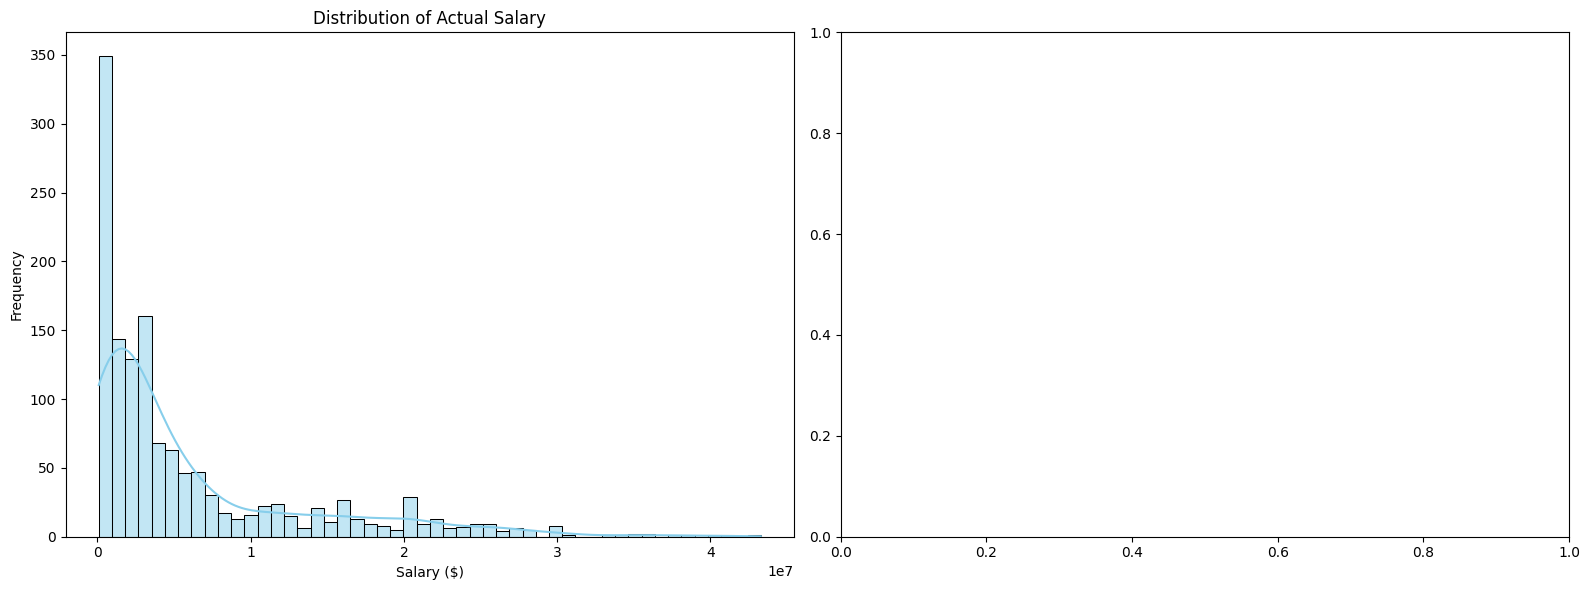

--- Salary Basic Statistics ---
count        1360.000000
mean      5985458.534559
std       7457692.064918
min         82809.000000
25%        850020.000000
50%       3000000.000000
75%       7400000.000000
max      43300000.000000
Name: target_salary, dtype: object


In [17]:


# グラフの作成
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. 生の年俸分布（Actual Salary）
sns.histplot(df_model['target_salary'], bins=50, kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Distribution of Actual Salary')
ax[0].set_xlabel('Salary ($)')
ax[0].set_ylabel('Frequency')

# 2. 対数変換後の年俸分布（Log Salary）
# 1を加えるのは、もし0がある場合にエラーを防ぐため（log1p）
#df_model['log_salary'] = np.log1p(df_model['target_salary'])
#sns.histplot(df_model['log_salary'], bins=30, kde=True, ax=ax[1], color='salmon')
#ax[1].set_title('Distribution of Log-Transformed Salary')
#ax[1].set_xlabel('Log(Salary)')
#ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# 基本統計量の確認
print("--- Salary Basic Statistics ---")
print(df_model['target_salary'].describe().apply(lambda x: format(x, 'f')))

In [18]:
print(df_model[df_model['target_salary'] < 500000][['Name_Clean', 'target_salary', 'PA']])

         Name_Clean  target_salary   PA
0         Ben Gamel       464757.0  550
55     Chris Taylor       485218.0  568
72      Javier Báez       199355.0  186
73      Javier Báez       199355.0  186
74      Javier Báez       199355.0  186
...             ...            ...  ...
1332  Franmil Reyes       184032.0  354
1333  Franmil Reyes       184032.0  354
1348  Franmil Reyes       184032.0  548
1349  Franmil Reyes       184032.0  548
1350  Franmil Reyes       184032.0  548

[144 rows x 3 columns]


In [19]:
# 最低年俸（約74万ドル）を基準に設定

min_salary_threshold = 700000

# フィルタリング実行
df_model_cleaned = df_model[df_model['target_salary'] >= min_salary_threshold].copy()

print(f"除去前のデータ件数: {len(df_model)}件")
print(f"除去後のデータ件数: {len(df_model_cleaned)}件")
print(f"除去された人数: {len(df_model) - len(df_model_cleaned)}人")

除去前のデータ件数: 1360件
除去後のデータ件数: 1056件
除去された人数: 304人


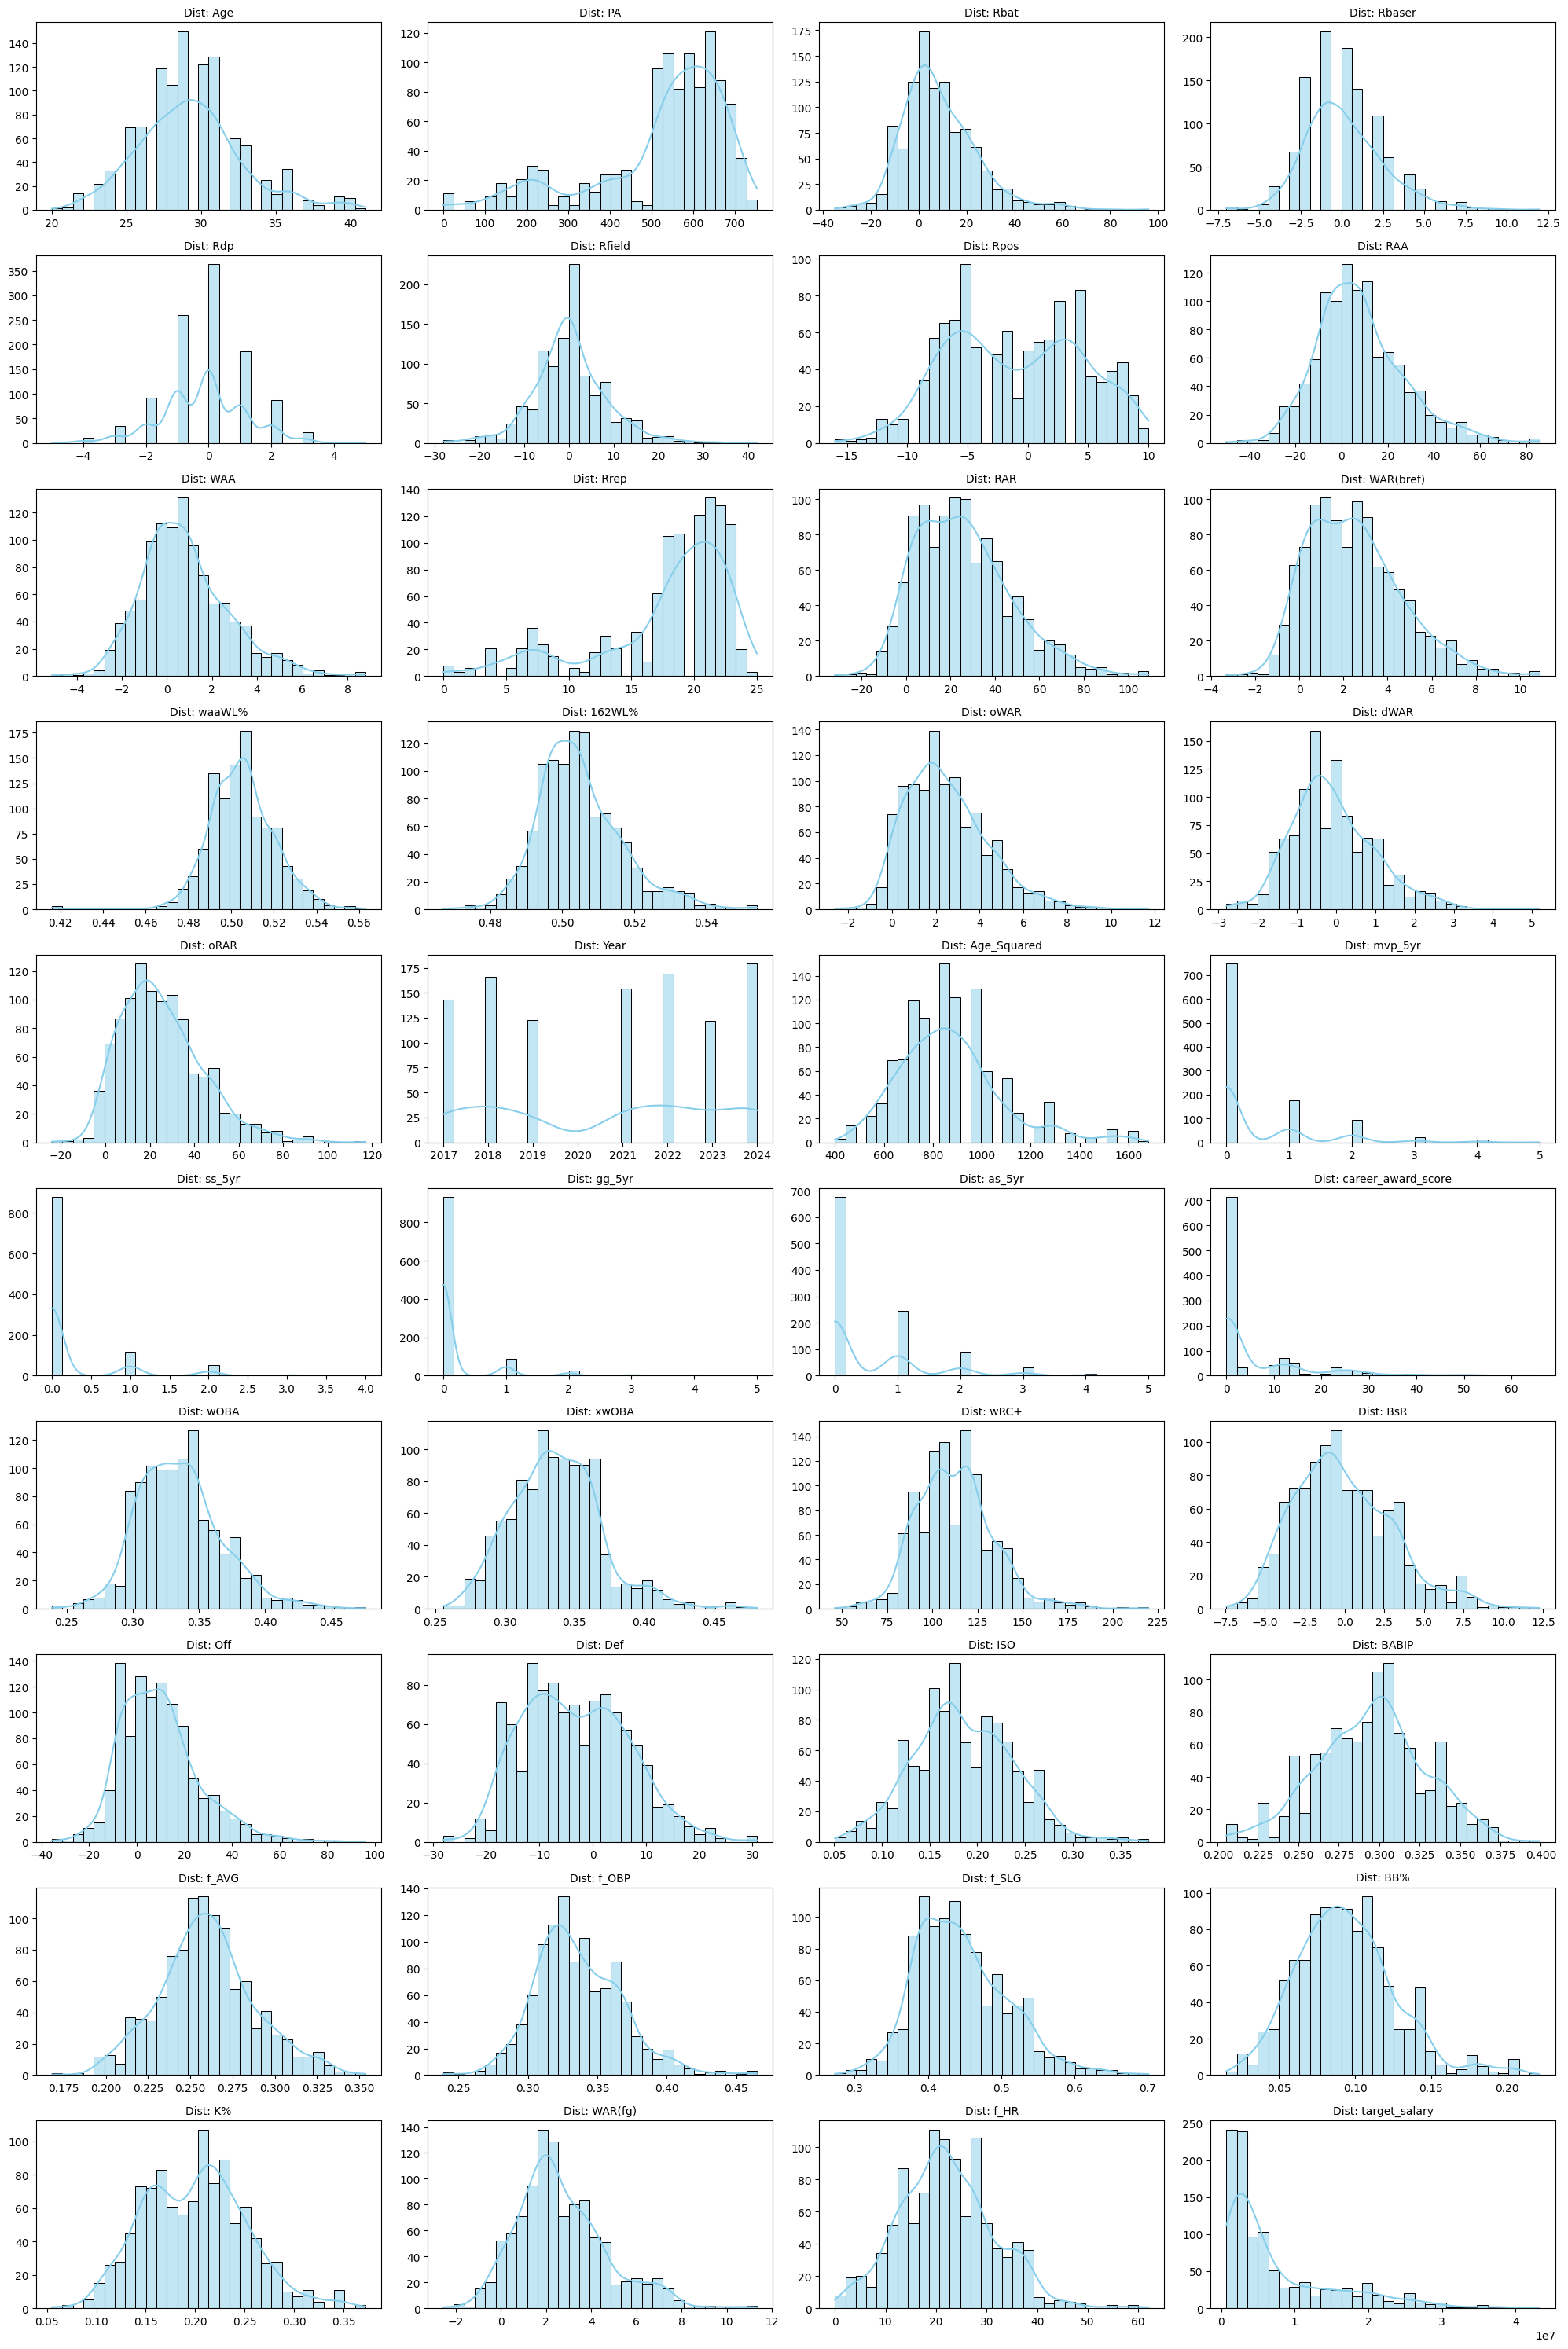

In [20]:
# 数値データのみ抽出
data_num = df_model_cleaned[num_cols]

# 指標の数に合わせてグリッドを自動計算
n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data_num[col], bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Dist: {col}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# 余った空白グラフを消す
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [21]:
# 1. 全数値指標の相関行列
full_corr = df_model_cleaned.select_dtypes(include=[np.number]).corr()

# 2. 相関が0.9以上のペアを抽出
high_corr_list = []
for i in range(len(full_corr.columns)):
    for j in range(i):
        coef = full_corr.iloc[i, j]
        if abs(coef) > 0.9:
            high_corr_list.append({
                'Feature 1': full_corr.columns[i],
                'Feature 2': full_corr.columns[j],
                'Correlation': coef
            })

# 結果を表示
df_high_corr = pd.DataFrame(high_corr_list)
print("--- 相関が0.9以上のペア（ ---")
print(df_high_corr.sort_values(by='Correlation', ascending=False))

--- 相関が0.9以上のペア（ ---
             Feature 1  Feature 2  Correlation
20                oRAR       oWAR     0.998936
6            WAR(bref)        RAR     0.997792
0                  WAA        RAA     0.996893
21         Age_Squared        Age     0.996132
11              162WL%        RAA     0.990857
1                 Rrep         PA     0.990341
12              162WL%        WAA     0.988465
22  career_award_score    mvp_5yr     0.987312
5            WAR(bref)        WAA     0.971886
28                 Off       wRC+     0.970456
2                  RAR        RAA     0.969266
4            WAR(bref)        RAA     0.968467
3                  RAR        WAA     0.968037
25                wRC+       wOBA     0.964928
13              162WL%        RAR     0.962525
14              162WL%  WAR(bref)     0.962084
27                 Off       wOBA     0.951880
30                f_HR        ISO     0.947692
24                wRC+       Rbat     0.933065
7               waaWL%        RAA     0

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 診断対象にする特徴量（前回の精鋭リスト + α）
# NaNがあるとエラーになるため、一度dropnaするか、平均値で埋める
vif_target_features = [
    'Age', 'PA', 'WAR(fg)', 'WAR(bref)', 'wRC+', 'xwOBA',
    'ISO', 'BB%', 'K%', 'f_AVG', 'f_HR', 'Def', 'BsR', 'Rpos','career_award_score'
]

X_vif = df_model_cleaned[vif_target_features].dropna()

# VIFの計算
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("\n--- VIFスコア ---")
print(vif_data.sort_values(by='VIF', ascending=False))


--- VIFスコア ---
               feature          VIF
4                 wRC+  1085.021226
5                xwOBA   506.325029
9                f_AVG   390.385130
6                  ISO   215.998263
2              WAR(fg)   103.895067
10                f_HR    98.756257
0                  Age    92.537235
7                  BB%    33.651420
8                   K%    25.232427
1                   PA    21.547920
3            WAR(bref)    13.515189
11                 Def    11.266224
12                 BsR     2.645621
13                Rpos     2.607962
14  career_award_score     1.788173


In [23]:
# 限界まで削ぎ落とした精鋭リスト
vif_final_features = [
    'Age',       # 年齢（必須）
    'Age_Squared',
    'PA',        # 出場機会（必須）
    'WAR(bref)', # 総合貢献度
    'wRC+',      # 打撃の質（これ1本に絞る）
    'BB%',       # 選球眼
    'K%',        # コンタクト能力
    'Def',       # 守備力
    'BsR',      # 走塁
    'career_award_score'

]

# 再度VIFを確認するためのコード
X_vif_final = df_model_cleaned[vif_final_features].dropna()
vif_data_final = pd.DataFrame()
vif_data_final["feature"] = X_vif_final.columns
vif_data_final["VIF"] = [variance_inflation_factor(X_vif_final.values, i) for i in range(len(X_vif_final.columns))]
print(vif_data_final.sort_values(by='VIF', ascending=False))

              feature         VIF
0                 Age  611.779771
1         Age_Squared  231.558518
4                wRC+  118.395563
2                  PA   21.579909
6                  K%   18.169644
5                 BB%   14.370776
3           WAR(bref)   13.722343
7                 Def    2.226656
9  career_award_score    1.653940
8                 BsR    1.411151


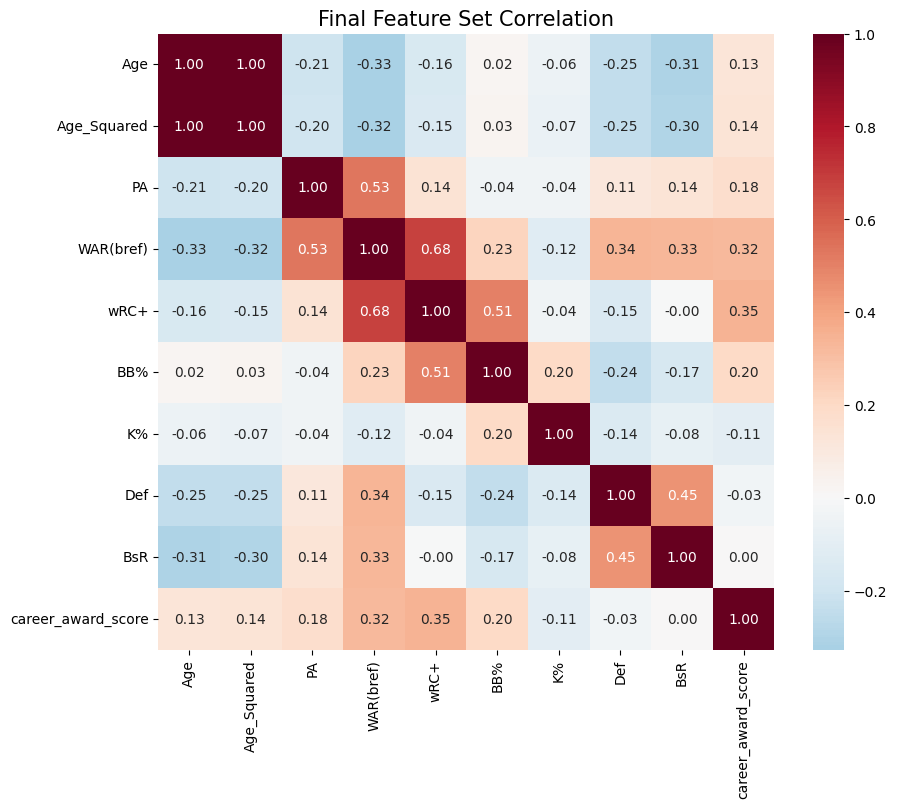

In [24]:


plt.figure(figsize=(10, 8))
sns.heatmap(df_model_cleaned[vif_final_features].corr(),
            annot=True,
            fmt=".2f",
            cmap='RdBu_r',
            center=0,
            square=True)

plt.title('Final Feature Set Correlation', fontsize=15)
plt.show()

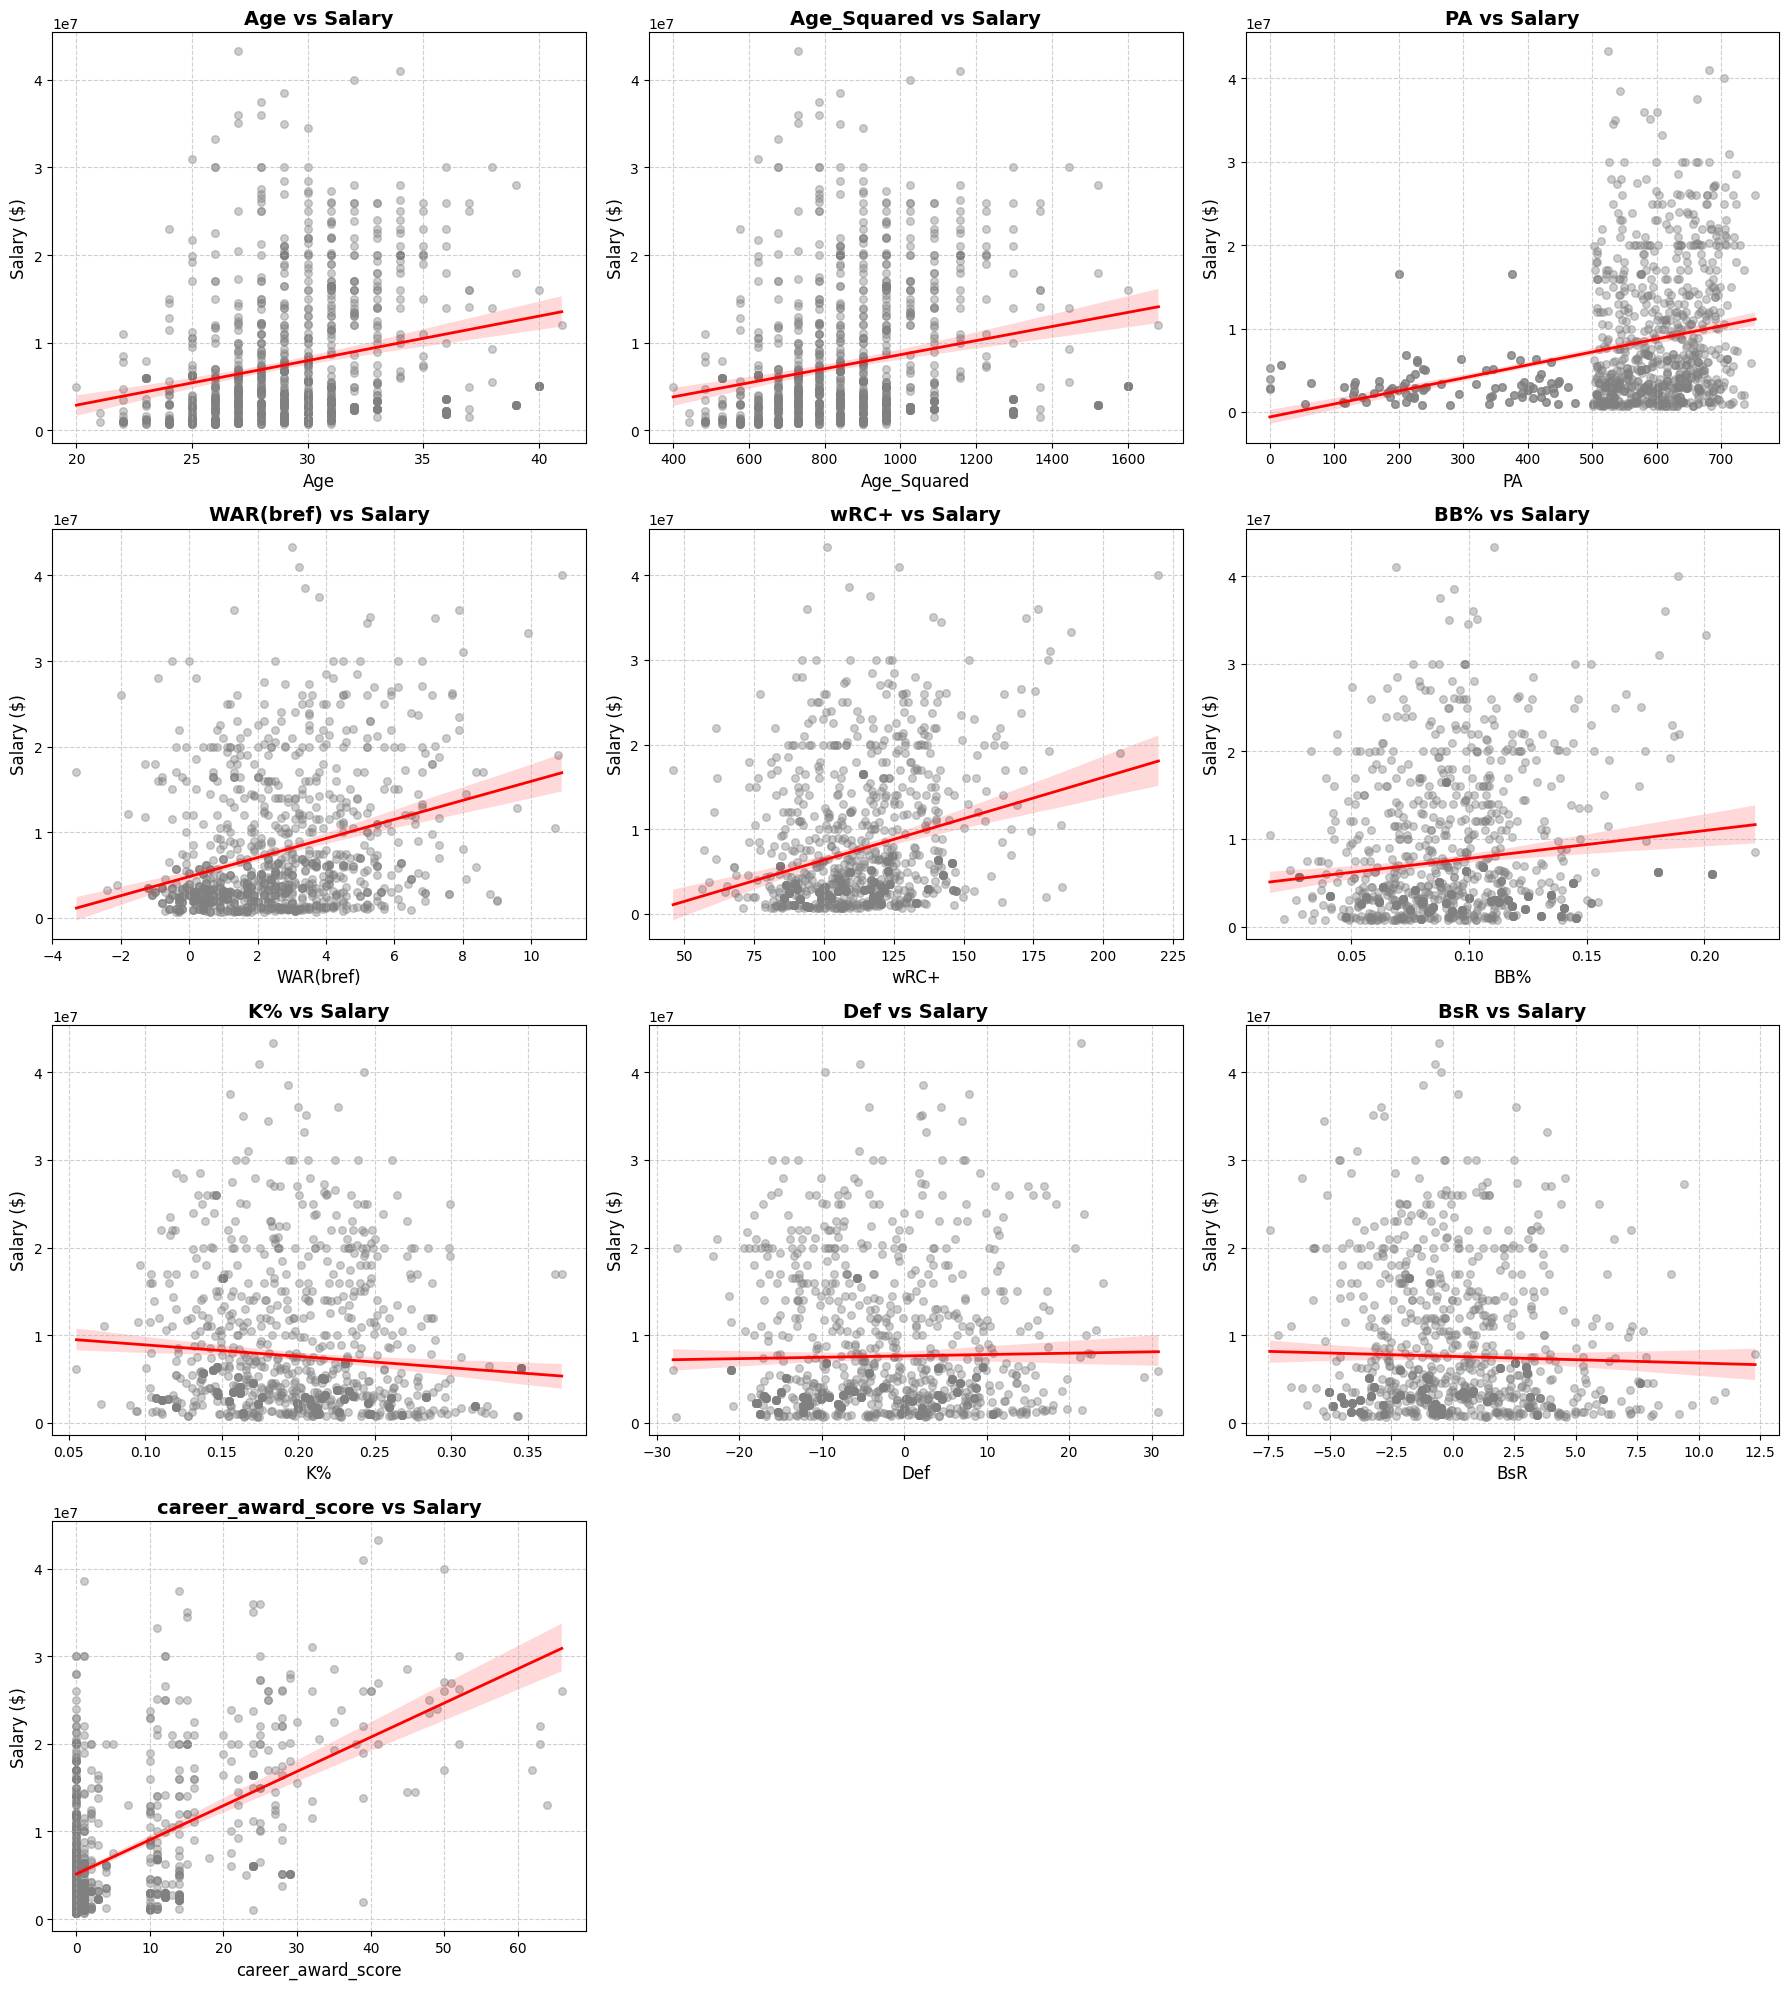

In [25]:
import math
import matplotlib.pyplot as plt
import seaborn as sns



# グリッドのサイズを計算
n_features = len(vif_final_features)
n_cols = 3 # 精鋭なので1行3つが見やすいです
n_rows = math.ceil(n_features / n_cols)

# プロットの作成
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(vif_final_features):
    # regplotで散布図と回帰直線を描画
    sns.regplot(data=df_model_cleaned, x=col, y='target_salary', ax=axes[i],
                scatter_kws={'alpha': 0.4, 's': 30, 'color': 'gray'},
                line_kws={'color': 'red', 'lw': 2})

    axes[i].set_title(f'{col} vs Salary', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Salary ($)', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)

# 余った空白のプロットを削除
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

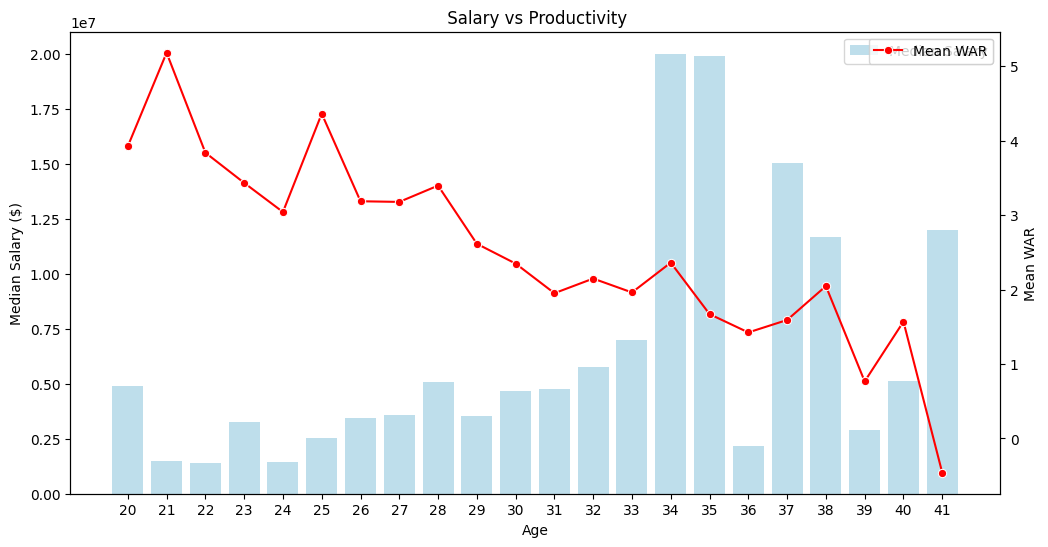

In [26]:
# 年齢ごとの年俸中央値と平均WARを算出
age_stats = df_model_cleaned.groupby('Age').agg({
    'target_salary': 'median',
    'WAR(fg)': 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

# 年俸の推移（棒グラフ）
sns.barplot(data=age_stats, x='Age', y='target_salary', ax=ax1, color='skyblue', alpha=0.6, label='Median Salary')
ax1.set_ylabel('Median Salary ($)')

# WARの推移（折れ線グラフ）
ax2 = ax1.twinx()
sns.lineplot(data=age_stats, x=age_stats.index, y='WAR(fg)', ax=ax2, color='red', marker='o', label='Mean WAR')
ax2.set_ylabel('Mean WAR')

plt.title(' Salary vs Productivity')
plt.show()

In [27]:
# 28歳以上をベテランとするフラグの作成
df_model_cleaned['is_veteran'] = (df_model_cleaned['Age'] >= 28).astype(int)

In [28]:
import re

def categorize_pos_bref(pos):
    pos = str(pos).upper()

    # 1. 捕手 (2)
    if '2' in pos: return 'Catcher'

    # 2. 内野手 (3:1B, 4:2B, 5:3B, 6:SS)
    if any(n in pos for n in ['3', '4', '5', '6']): return 'Infield'

    # 3. 外野手 (7:LF, 8:CF, 9:RF)
    if any(n in pos for n in ['7', '8', '9']): return 'Outfield'

    # 4. 指名打者 (D)
    if 'D' in pos: return 'DH'

    return 'Other'

# 適用
df_model_cleaned['Pos_Group'] = df_model_cleaned['Pos'].apply(categorize_pos_bref)

# 件数確認
print(df_model_cleaned['Pos_Group'].value_counts())

Pos_Group
Infield     653
Outfield    342
Catcher      40
DH           13
Other         8
Name: count, dtype: int64


/tmp/ipykernel_8706/2521855518.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model_cleaned, x='Pos_Group', y='target_salary', palette='Set2', showfliers=False)


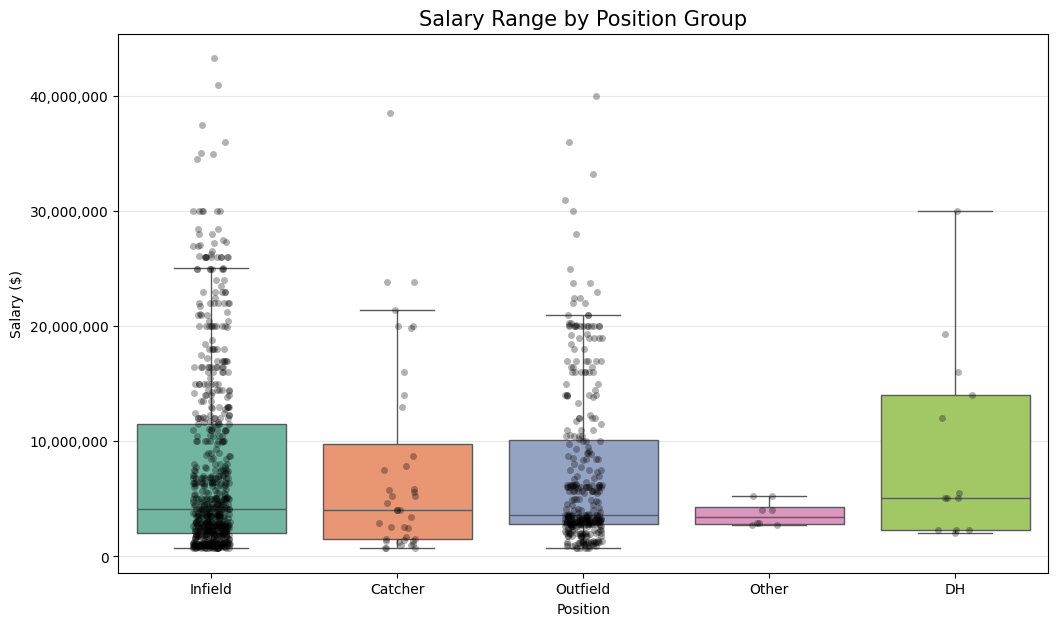

In [29]:
plt.figure(figsize=(12, 7))

# 箱ひげ図に個々のデータを重ねる（スウォームプロット）
sns.boxplot(data=df_model_cleaned, x='Pos_Group', y='target_salary', palette='Set2', showfliers=False)
sns.stripplot(data=df_model_cleaned, x='Pos_Group', y='target_salary', color='black', alpha=0.3, jitter=True)

plt.title('Salary Range by Position Group', fontsize=15)
plt.ylabel('Salary ($)')
plt.xlabel('Position')
# y軸を読みやすく（例：10Mなど）
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.grid(axis='y', alpha=0.3)
plt.show()

/tmp/ipykernel_8706/784984157.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model_cleaned, x='Team', y='target_salary', order=team_order, palette='vlag')


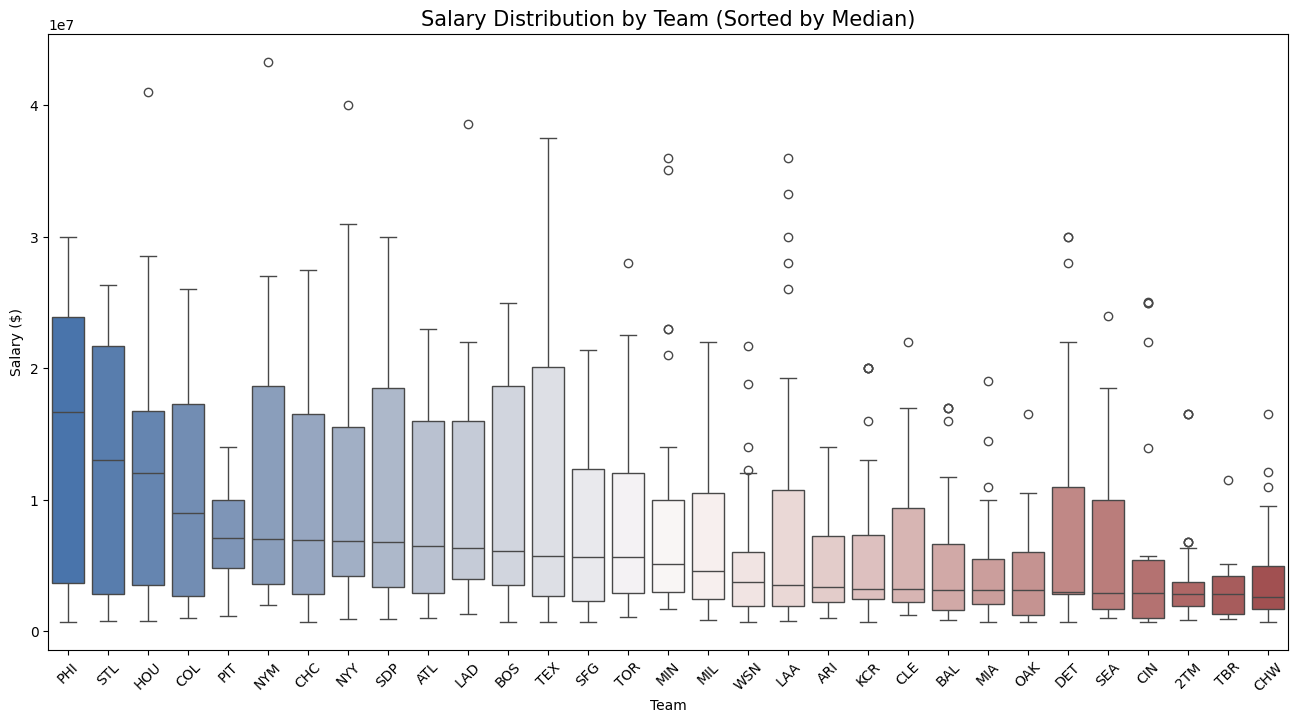

In [30]:
plt.figure(figsize=(16, 8))

# チームごとの中央値でソート
team_order = df_model_cleaned.groupby('Team')['target_salary'].median().sort_values(ascending=False).index

sns.boxplot(data=df_model_cleaned, x='Team', y='target_salary', order=team_order, palette='vlag')
plt.xticks(rotation=45)
plt.title('Salary Distribution by Team (Sorted by Median)', fontsize=15)
plt.ylabel('Salary ($)')
plt.show()

In [31]:



final_numeric_features = [
    'Age','Age_Squared', 'is_veteran', 'PA', 'WAR(bref)', 'wRC+', 'ISO', 'BB%', 'K%', 'Def', 'BsR', 'career_award_score'
]

# カテゴリ変数（チームとポジション）
final_category_features = ['Team', 'Pos_Group']



In [32]:
from sklearn.model_selection import train_test_split

# 3. ダミー変数化（drop_first=False で全カテゴリを保持）
#X = df_model_cleaned[final_numeric_features ]
#df_model = df_model_cleaned[df_model_cleaned['target_salary'] <= 20_000_000].copy()
X = df_model_cleaned[final_numeric_features + final_category_features]
X_final = pd.get_dummies(X, columns=['Team', 'Pos_Group'], drop_first=False)

y = np.log1p(df_model_cleaned['target_salary'])

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

print(f"--- 学習準備完了 ---")
print(f"学習サンプル数: {len(X_train)} 件")
print(f"テストサンプル数: {len(X_test)} 件")
print(f"特徴量の総数: {X_final.shape[1]} (チーム・ポジションのダミー変数を含む)")

--- 学習準備完了 ---
学習サンプル数: 844 件
テストサンプル数: 212 件
特徴量の総数: 48 (チーム・ポジションのダミー変数を含む)


In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# 1. モデル定義
model_rf = RandomForestRegressor(
    n_estimators=100,      # 木の数
    random_state=42,       # 再現性のためのシード
    n_jobs=-1              # 全CPUコアを使用して高速化
)

# 2. 学習
print("Training Random Forest model...")
model_rf.fit(X_train, y_train)

# 3. 予測と評価
y_pred_rf_log = model_rf.predict(X_test)

# --- 評価用 ---
# 対数変換を元に戻して(expm1)ドル単位で誤差を計算
mae_rf_vet = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_rf_log))

print(f"Random Forest  MAE: ${mae_rf_vet:,.0f}")

Training Random Forest model...
Random Forest  MAE: $2,978,621


In [34]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

# 1. モデル定義
model_lgb = LGBMRegressor(
    n_estimators=100,      # 木の数
    learning_rate=0.05,    # 学習率
    random_state=42,       # 再現性のためのシード
    n_jobs=-1              # 全CPUコアを使用
)


model_lgb.fit(X_train, y_train)

# 3. 予測と評価
y_pred_lgb_log = model_lgb.predict(X_test)

# --- 評価用 ---
# 対数変換を元に戻して(expm1)ドル単位で誤差を計算
mae_lgb_vet = mean_absolute_error(
    np.expm1(y_test),
    np.expm1(y_pred_lgb_log)
)

print(f"LightGBM MAE: ${mae_lgb_vet:,.0f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018216 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1977
[LightGBM] [Info] Number of data points in the train set: 844, number of used features: 38
[LightGBM] [Info] Start training from score 15.382218
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM MAE: $3,005,125


In [35]:
from xgboost import XGBRegressor
import xgboost as xgb
model_xgb = xgb.XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42
)

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_xgb_log = model_xgb.predict(X_test)
y_pred = np.expm1(y_pred_xgb_log) # 対数から戻す


mae = mean_absolute_error(np.expm1(y_test), y_pred)
print(f"Mean Absolute Error: ${mae:,.0f}")

Mean Absolute Error: $2,878,631


In [36]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error

# 1. 各モデルの予測値を実際のドル単位（反対数）に変換
y_actual = np.expm1(y_test)
results_lgb = np.expm1(y_pred_lgb_log)
results_xgb = np.expm1(y_pred_xgb_log)
results_rf = np.expm1(y_pred_rf_log)

# 2. まとめのデータフレーム作成
evaluation_summary = [
    {
        "Model": "LightGBM",
        "MAE (USD)": mean_absolute_error(y_actual, results_lgb),
        "MAPE (%)": mean_absolute_percentage_error(y_actual, results_lgb) * 100,
        "R2 Score": r2_score(y_test, y_pred_lgb_log)
    },
    {
        "Model": "XGBoost",
        "MAE (USD)": mean_absolute_error(y_actual, results_xgb),
        "MAPE (%)": mean_absolute_percentage_error(y_actual, results_xgb) * 100,
        "R2 Score": r2_score(y_test, y_pred_xgb_log)
    },
    {
        "Model": "Random Forest",
        "MAE (USD)": mean_absolute_error(y_actual, results_rf),
        "MAPE (%)": mean_absolute_percentage_error(y_actual, results_rf) * 100,
        "R2 Score": r2_score(y_test, y_pred_rf_log)
    }
]

summary_df = pd.DataFrame(evaluation_summary)

# 表示用にフォーマットを整える（計算用の数値は保持しつつ、見た目を変える）
display_df = summary_df.copy()
display_df["MAE (USD)"] = display_df["MAE (USD)"].apply(lambda x: f"${x:,.0f}")
display_df["MAPE (%)"] = display_df["MAPE (%)"].apply(lambda x: f"{x:.2f}%")
display_df["R2 Score"] = display_df["R2 Score"].apply(lambda x: f"{x:.4f}")

# 3. 表示
print("="*60)
print("      MLB Salary Prediction: Final Evaluation")
print("="*60)
print(display_df.to_string(index=False))
print("-" * 60)

# 4. 最も良いモデルを自動判定（MAPEが最小のもの）
# MAEでも良いですが、相対的な精度の指標としてMAPEを使用します
best_model_idx = summary_df['MAPE (%)'].idxmin()
best_model_name = summary_df.loc[best_model_idx, 'Model']

print(f"★ 今回のデータセットで最も優秀なモデル: {best_model_name}")

      MLB Salary Prediction: Final Evaluation
        Model  MAE (USD) MAPE (%) R2 Score
     LightGBM $3,005,125   60.57%   0.5802
      XGBoost $2,878,631   56.62%   0.6018
Random Forest $2,978,621   56.88%   0.5787
------------------------------------------------------------
★ 今回のデータセットで最も優秀なモデル: XGBoost


/tmp/ipykernel_8706/1837320197.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_20_features, palette='viridis')


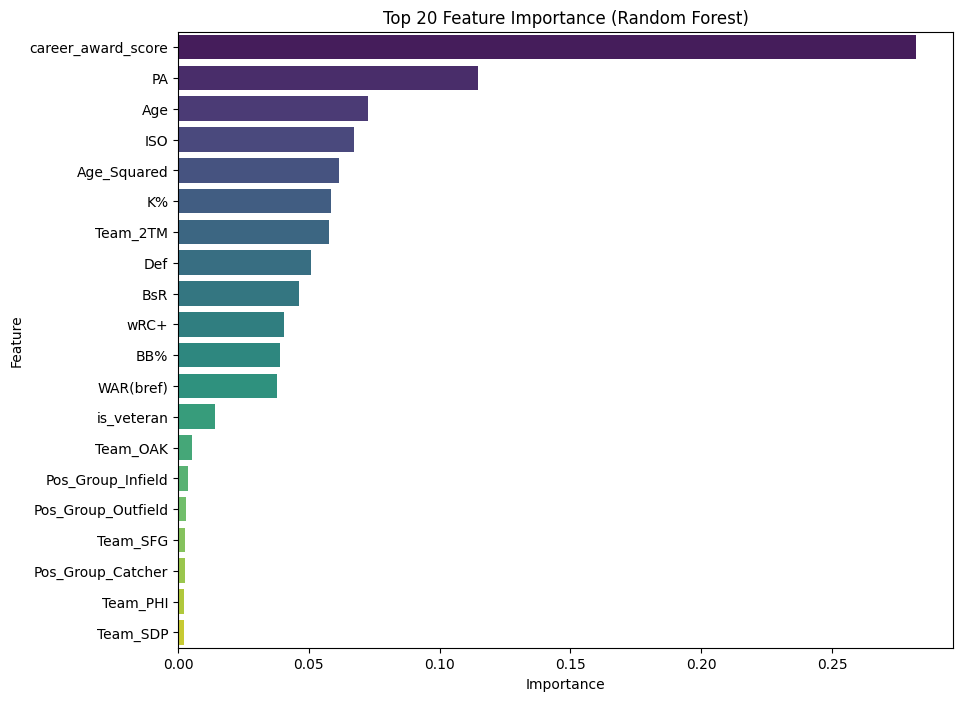

In [37]:
# Random Forest の重要度を可視化
import pandas as pd
import matplotlib.pyplot as plt

# model は学習済みの RandomForestRegressor
importances = model_rf.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 上位20個を表示
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_20_features, palette='viridis')
plt.title('Top 20 Feature Importance (Random Forest)')
plt.show()

/tmp/ipykernel_8706/3790494728.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x='Salary_Range', y='Residual', palette='vlag')


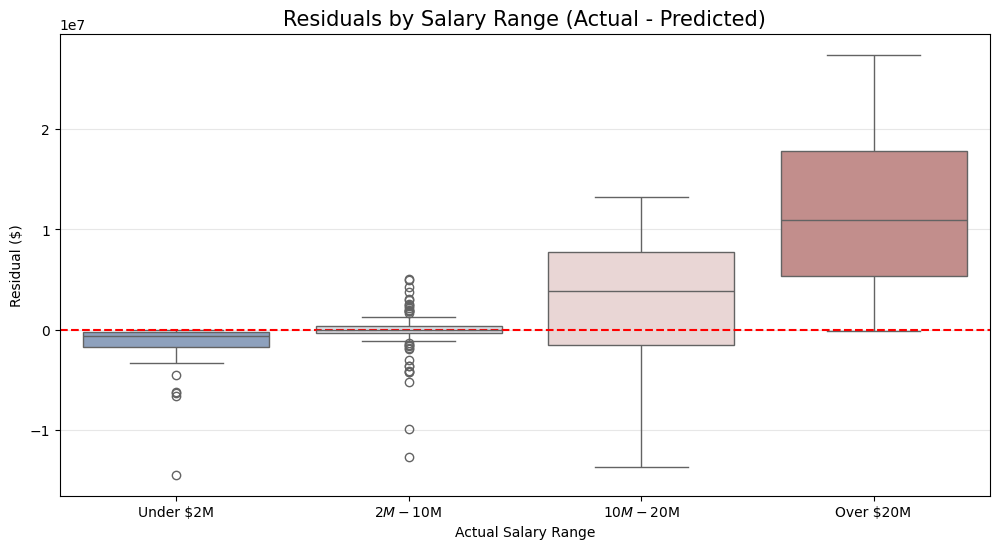

--- 年俸帯別・残差統計 ---
                      mean           std  count
Salary_Range                                   
Under $2M    -1.422020e+06  2.396959e+06     53
$2M-$10M     -1.347138e+05  2.247891e+06    108
$10M-$20M     3.265983e+06  6.122038e+06     29
Over $20M     1.212368e+07  8.511874e+06     22


/tmp/ipykernel_8706/3790494728.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  residual_stats = results_df.groupby('Salary_Range')['Residual'].agg(['mean', 'std', 'count'])


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 予測結果の集約（Random Forestの結果を使用する例）
# 注: すでに y_test と y_pred_rf_log がある前提です
results_df = pd.DataFrame({
    'Actual': np.expm1(y_test),
    'Predicted': np.expm1(y_pred_rf_log)
})

# 残差（誤差）を計算
results_df['Residual'] = results_df['Actual'] - results_df['Predicted']

# 2. 年俸帯別のグループ分け（4分位で分割、またはキリの良い数字で分割）
# ここでは分かりやすく金額でラベル付けします
bins = [0, 2000000, 10000000, 20000000, np.inf]
labels = ['Under $2M', '$2M-$10M', '$10M-$20M', 'Over $20M']
results_df['Salary_Range'] = pd.cut(results_df['Actual'], bins=bins, labels=labels)

# 3. 可視化：年俸帯別の残差分布
plt.figure(figsize=(12, 6))
sns.boxplot(data=results_df, x='Salary_Range', y='Residual', palette='vlag')
plt.axhline(y=0, color='red', linestyle='--') # 誤差ゼロのライン

plt.title('Residuals by Salary Range (Actual - Predicted)', fontsize=15)
plt.ylabel('Residual ($)')
plt.xlabel('Actual Salary Range')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4. 数値での確認
residual_stats = results_df.groupby('Salary_Range')['Residual'].agg(['mean', 'std', 'count'])
print("--- 年俸帯別・残差統計 ---")
print(residual_stats)

In [39]:

results_df['Absolute_Error'] = results_df['Residual'].abs()
# 1. 予測結果と元のデータ（選手名や年齢など）をインデックスで結合
# 念のため、必要な列（Name, Age, Tm, target_salaryなど）に絞って結合します
comparison_df = results_df.join(df_model_cleaned[['Name_Clean', 'Age', 'Team']])

results_df['Absolute_Error'] = results_df['Residual'].abs()

# 2. 絶対誤差でソートしてトップ10を抽出
top_errors_named = comparison_df.sort_values('Absolute_Error', ascending=False).head(10)

# 3. 表示（見やすくするために列を整理）
print("--- 予測誤差が大きい選手トップ10 ---")
print(top_errors_named[['Name_Clean', 'Age', 'Team', 'Actual', 'Predicted', 'Residual']])

--- 予測誤差が大きい選手トップ10 ---
          Name_Clean  Age Team      Actual     Predicted      Residual
416       Mike Trout   26  LAA  33250000.0  5.866849e+06  2.738315e+07
137   Miguel Cabrera   38  DET  30000000.0  3.430111e+06  2.656989e+07
360    Manny Machado   26  SDP  30000000.0  4.220750e+06  2.577925e+07
135   Miguel Cabrera   34  DET  28000000.0  3.961630e+06  2.403837e+07
417       Mike Trout   27  LAA  36000000.0  1.765932e+07  1.834068e+07
673     Bryce Harper   25  WSN  21725000.0  3.444940e+06  1.828006e+07
76       Javier Báez   30  DET  22000000.0  5.746138e+06  1.625386e+07
454  Freddie Freeman   27  ATL  20500000.0  5.388570e+06  1.511143e+07
381  Adley Rutschman   26  BAL   1048610.0  1.546341e+07 -1.441480e+07
362    Manny Machado   29  SDP  30000000.0  1.589907e+07  1.410093e+07


In [40]:
# DuckDBの内容をDriveに同期
con.close()
shutil.copy(LOCAL_DB_PATH, os.path.join(DRIVE_PATH, 'mlb_analytics.duckdb'))
print("Database synced to Google Drive.")

Database synced to Google Drive.
